
First 5 rows of dataset:
    pregnant  Glucose  bp  skin  insulin   BMI  Pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  768 non-null    int64  
 1   Glucose   768 non-null    int64  
 2   bp        768 non-null    int64  
 3   skin      768 non-null    int64  
 4   insulin   768 non-null    int64  
 5   BMI       768 non-null    float64
 6   Pedigree  768 non-null    float64
 7   age       768 non-null    int64  
 8   label     768 non-null    int64  
dtypes: float64(

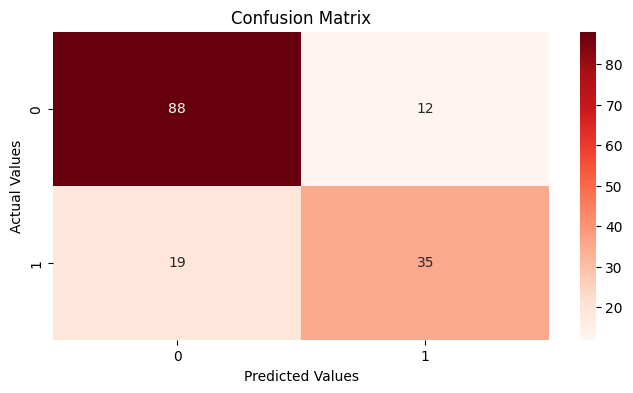

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

col_names = ['pregnant', 'Glucose', 'bp', 'skin', 'insulin', 'BMI', 'Pedigree', 'age', 'label']
pima = pd.read_csv("diabetes.csv")
pima.columns = col_names

print("\nFirst 5 rows of dataset:\n", pima.head())
print("\nDataset Info:\n")
print(pima.info())

feature_cols = ['pregnant', 'insulin', 'BMI', 'age', 'Glucose', 'bp', 'Pedigree']
X = pima[feature_cols]
y = pima['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=5)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

train_acc = model.score(X_train, y_train)
print("\nThe Accuracy for Training Set is {:.2f}%".format(train_acc * 100))

test_acc = accuracy_score(y_test, y_pred)
print("The Accuracy for Test Set is {:.2f}%".format(test_acc * 100))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 4))
plt.title("Confusion Matrix")
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.savefig("confusion_matrix.png")
plt.show()
